## Chapter 2 exercises

In [2]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.7.0
tiktoken version: 0.9.0


### Exercise 2.1 Byte pair encoding of unknown words

Try the BPE tokenizer from the tiktoken library on the unknown words “Akwirw ier” and
print the individual token IDs. Then, call the decode function on each of the resulting
integers in this list to reproduce the mapping shown in figure 2.11. Lastly, call the
decode method on the token IDs to check whether it can reconstruct the original

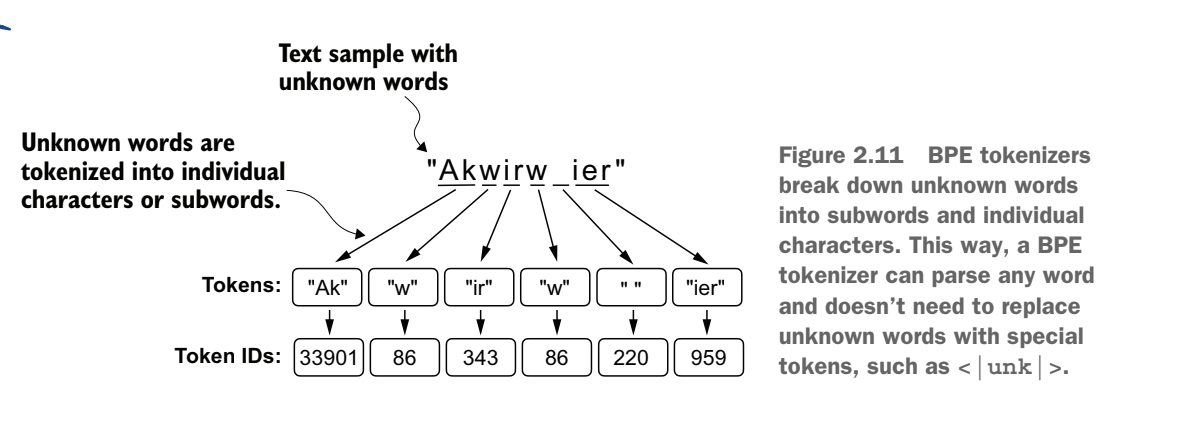

In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
ids = tokenizer.encode("Akwirw ier")
print(ids)

[33901, 86, 343, 86, 220, 959]


In [7]:
for id in ids:
    print(f"id -> {tokenizer.decode([id])}")

id -> Ak
id -> w
id -> ir
id -> w
id ->  
id -> ier


## Exercise 2.2 Data loaders with different strides and context sizes

To develop more intuition for how the data loader works, try to run it with different
settings such as max_length=2 and stride=2, and max_length=8 and stride=2.

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        self.stride = stride
        self.max_length = max_length

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1"

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    
def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0,
):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )

    return dataloader, dataset

In [13]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [ ]:
dataloader, dataset = create_dataloader_v1(
    raw_text, batch_size=2, max_length=2, stride=2, shuffle=False
)

data_iter = iter(dataloader)

for i, (inputs, targets) in enumerate(data_iter):
    print(f"Batch {i}:")
    print(f"  Inputs: {inputs}")
    print(f"  Targets: {targets}")
    

    if i >= 10:
        break
    
    

Batch 0:
  Inputs: tensor([[  40,  367],
        [2885, 1464]])
  Targets: tensor([[ 367, 2885],
        [1464, 1807]])
Batch 1:
  Inputs: tensor([[1807, 3619],
        [ 402,  271]])
  Targets: tensor([[ 3619,   402],
        [  271, 10899]])
Batch 2:
  Inputs: tensor([[10899,  2138],
        [  257,  7026]])
  Targets: tensor([[ 2138,   257],
        [ 7026, 15632]])
Batch 3:
  Inputs: tensor([[15632,   438],
        [ 2016,   257]])
  Targets: tensor([[ 438, 2016],
        [ 257,  922]])
Batch 4:
  Inputs: tensor([[ 922, 5891],
        [1576,  438]])
  Targets: tensor([[5891, 1576],
        [ 438,  568]])
Batch 5:
  Inputs: tensor([[568, 340],
        [373, 645]])
  Targets: tensor([[ 340,  373],
        [ 645, 1049]])
Batch 6:
  Inputs: tensor([[1049, 5975],
        [ 284,  502]])
  Targets: tensor([[5975,  284],
        [ 502,  284]])
Batch 7:
  Inputs: tensor([[ 284, 3285],
        [ 326,   11]])
  Targets: tensor([[3285,  326],
        [  11,  287]])
Batch 8:
  Inputs: tensor([[

Visualization for max_length=2, stride=2:


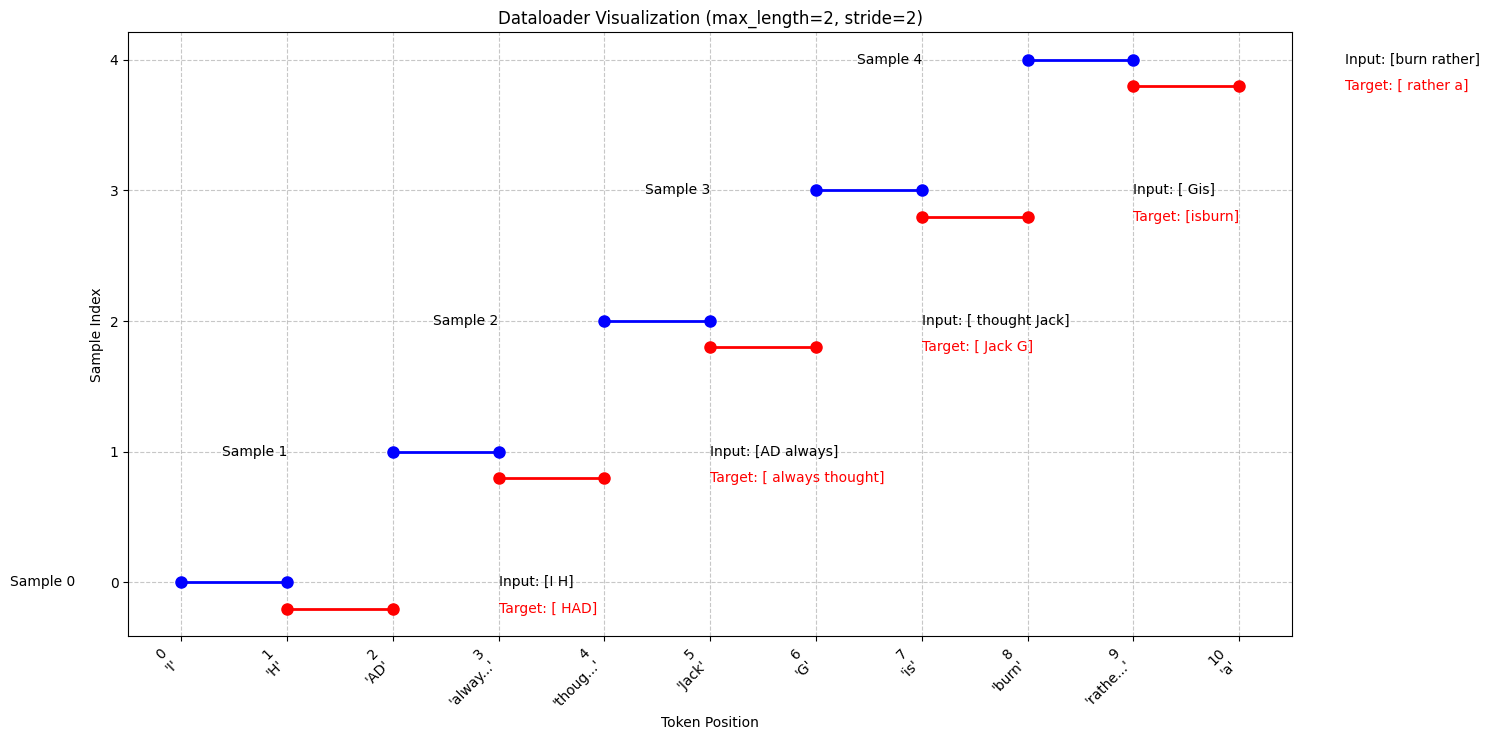


Visualization for max_length=8, stride=2:


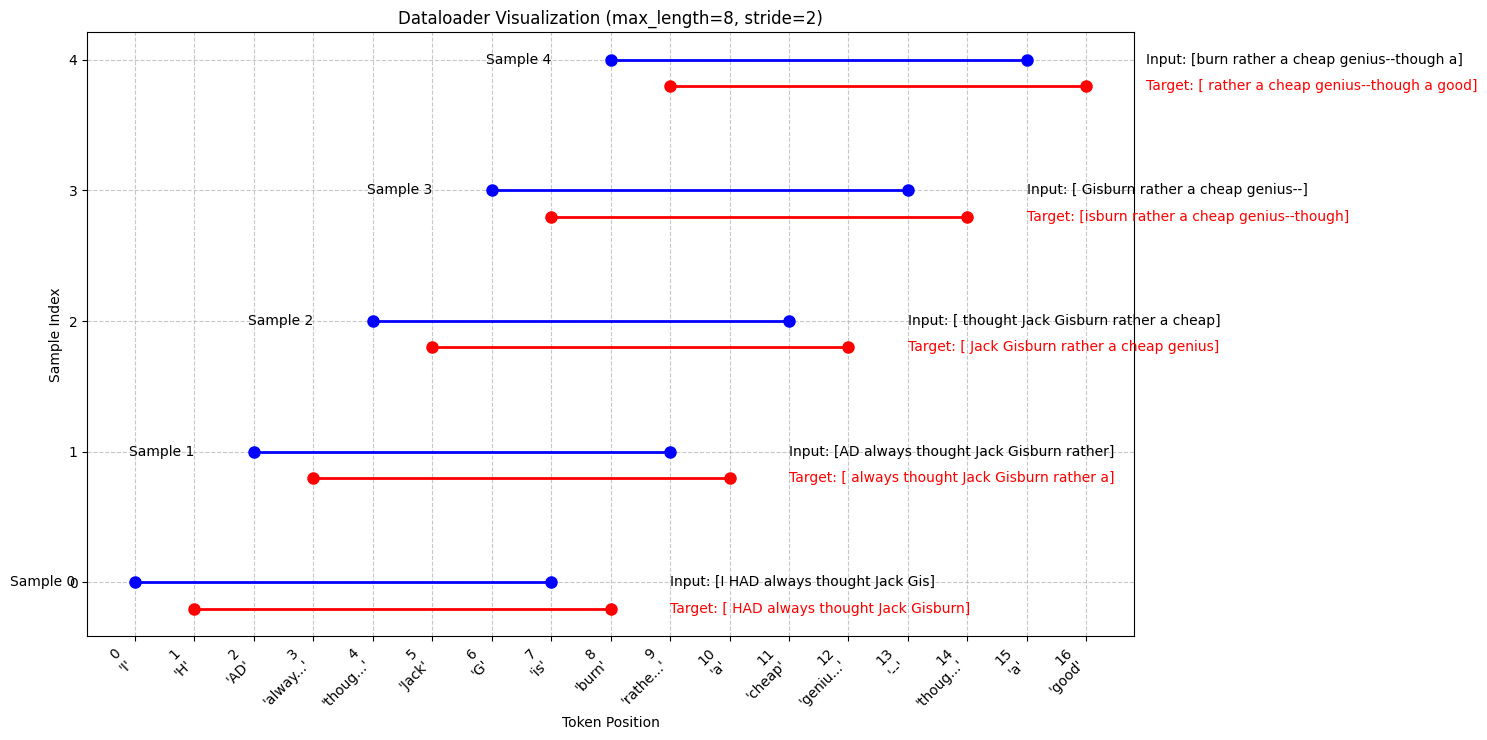


Visualization for max_length=8, stride=4:


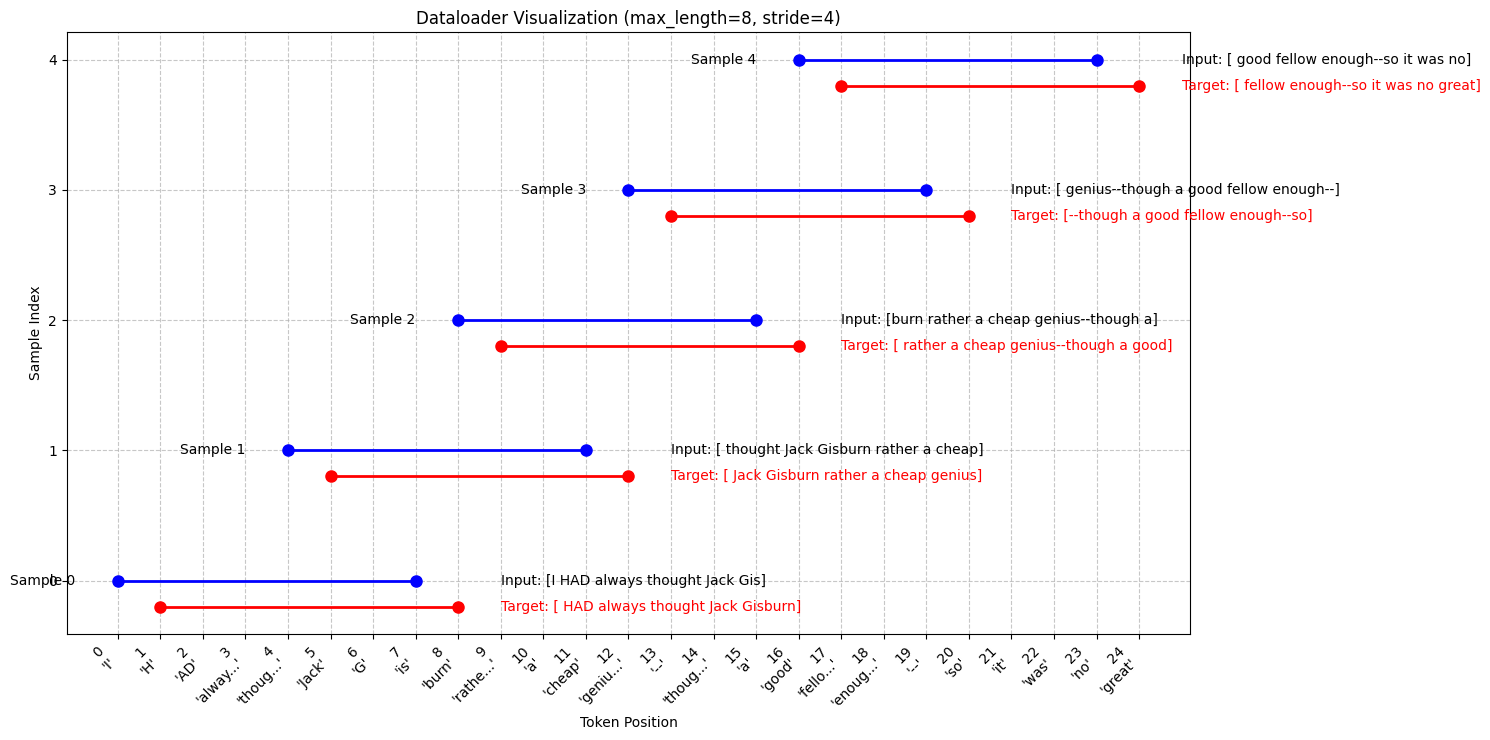


Visualization for max_length=16, stride=8:


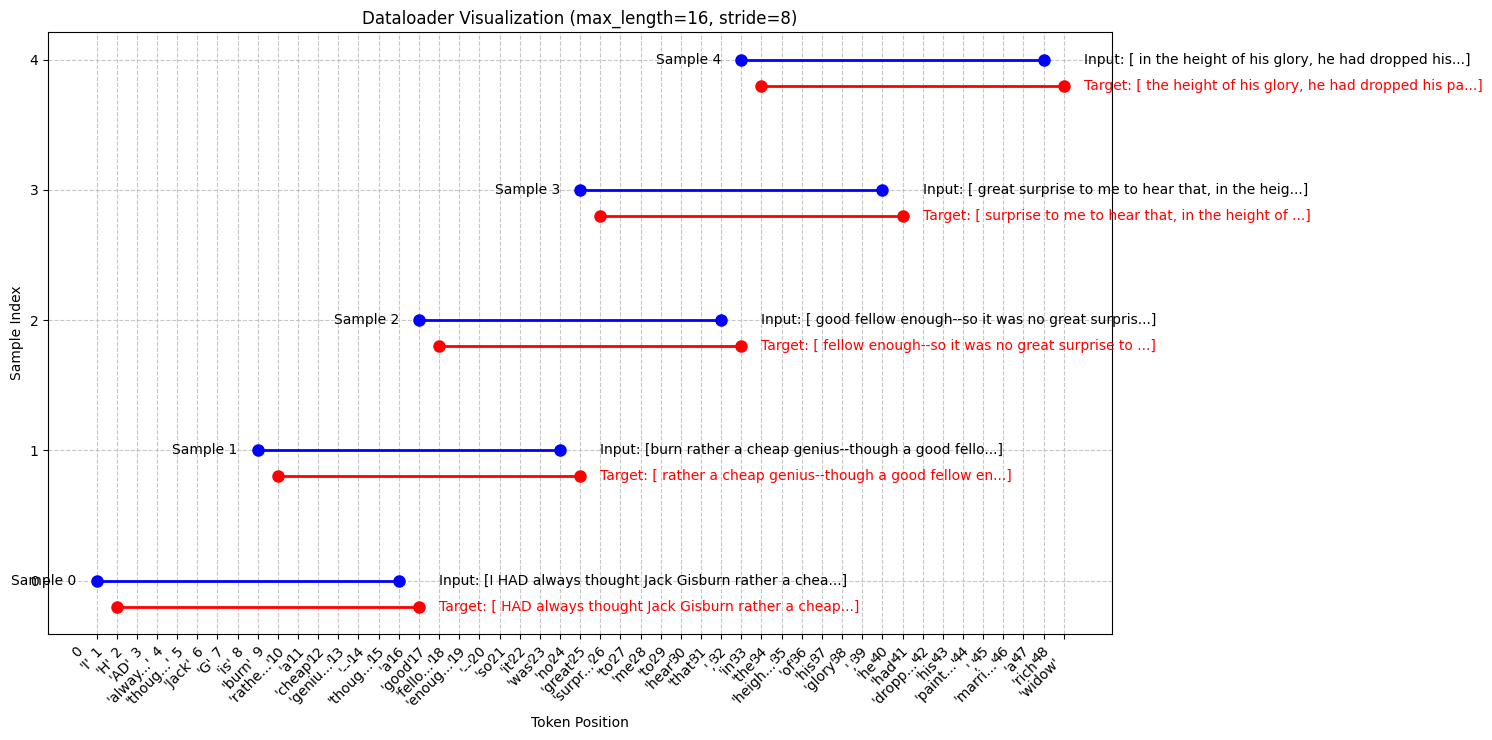

In [68]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_dataloader_samples(text, max_length, stride, num_samples=5):
    """
    Visualize how the dataloader slices the text with different max_length and stride settings.
    
    Args:
        text: Raw text to visualize
        max_length: Context size for inputs
        stride: Step size between consecutive samples
        num_samples: Number of samples to visualize
    """
    # Get a small subset of the text to visualize
    tokenizer = tiktoken.get_encoding("gpt2")
    tokens = tokenizer.encode(text[:500], allowed_special={"<|endoftext|>"})
    decoded = [tokenizer.decode([t]) for t in tokens]
    
    # Create a figure
    plt.figure(figsize=(15, num_samples*1.5))
    
    # Generate dataset samples for visualization
    samples = []
    for i in range(0, len(tokens) - max_length, stride):
        if len(samples) >= num_samples:
            break
        input_chunk = tokens[i:i + max_length]
        target_chunk = tokens[i + 1:i + max_length + 1]
        samples.append((i, i + max_length, input_chunk, target_chunk))
    
    # Calculate the total span of all samples for x-axis scaling
    max_end = max(end for _, end, _, _ in samples) if samples else 0
    
    # Plot each sample as a span on the timeline
    for idx, (start, end, inputs, targets) in enumerate(samples):
        # Plot input span
        plt.plot([start, end-1], [idx, idx], 'bo-', linewidth=2, markersize=8)
        
        # Plot target span (shifted by 1)
        plt.plot([start+1, end], [idx-0.2, idx-0.2], 'ro-', linewidth=2, markersize=8)
        
        # Add sample index
        plt.text(start-1, idx, f"Sample {idx}", va='center', ha='right')
        
        # Add sample details
        input_str = ''.join([tokenizer.decode([t]) for t in inputs])
        target_str = ''.join([tokenizer.decode([t]) for t in targets])
        if len(input_str) > 50:
            input_str = input_str[:47] + "..."
        if len(target_str) > 50:
            target_str = target_str[:47] + "..."
        plt.text(end+1, idx, f"Input: [{input_str}]", va='center', ha='left')
        plt.text(end+1, idx-0.2, f"Target: [{target_str}]", va='center', ha='left', color='red')
    
    # Improved token labeling for better readability
    min_start = min(start for start, _, _, _ in samples) if samples else 0
    
    # For larger sequence lengths, we'll show fewer token labels
    if max_length > 10:
        # Show only a subset of tokens to avoid overcrowding
        step = max(1, max_length // 10)
        token_positions = np.arange(min_start, max_end+1, step)
    else:
        token_positions = np.arange(min_start, max_end+1)
    
    # Create cleaner labels
    token_labels = []
    for i in token_positions:
        if i < len(decoded):
            # Replace problematic characters and limit length
            token_text = decoded[i].replace('\n', '⏎').strip()
            if len(token_text) > 5:
                token_text = token_text[:5] + "..."
            token_labels.append(f"{i}\n'{token_text}'")
        else:
            token_labels.append("")
    
    plt.xticks(token_positions, token_labels, rotation=45, ha='right')
    
    # Add gridlines for better readability
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Set plot title and labels
    plt.title(f"Dataloader Visualization (max_length={max_length}, stride={stride})")
    plt.xlabel("Token Position")
    plt.ylabel("Sample Index")
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

# Example usage with different settings
print("Visualization for max_length=2, stride=2:")
visualize_dataloader_samples(raw_text, max_length=2, stride=2)

print("\nVisualization for max_length=8, stride=2:")
visualize_dataloader_samples(raw_text, max_length=8, stride=2)

print("\nVisualization for max_length=8, stride=4:")
visualize_dataloader_samples(raw_text, max_length=8, stride=4)

# Also try a larger context size
print("\nVisualization for max_length=16, stride=8:")
visualize_dataloader_samples(raw_text, max_length=16, stride=8)